# 데이터기반공학해석 (2026-2) — 과제 1회차 Part B: 희소회귀

| 문항 | 내용 | 필요한 데이터 |
|---|---|---|
| 1 | 교재 §3.5 LASSO 예제(그림 7) 재현 — 최소제곱·LASSO(10-겹 CV, 1-SE)·de-bias·STLSQ 계수를 한 표로 + 손계산 예 1의 ℓ₁ 검산 | 없음(난수 생성) |
| 2 | 배포 풀이 `w04_solution_bugs.m` 오류 찾기 — 7건: 위반한 식, 수정 코드, 수정 전후 수치 | `w04_solution_bugs.m` (노트북 폴더) |
| 3 | 개인 탐구: CNT 공진기 FRC 주기응답에서 후보항 라이브러리 Θ를 만들고 STLSQ로 운동방정식을 복원 — λ에 따른 활성 항 수–검증오차 곡선과 선택 근거(CV·AIC) | `result_0819/…AC_0.19…HBM_coeffs_branch01/02.csv` (Part A와 같은 파일) |



In [1]:
# 공통 환경 설정 ---------------------------------------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import os, warnings
warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.family": "DejaVu Sans"})
pd.set_option("display.float_format", lambda v: f"{v:.4g}")

NB_DIR   = Path.cwd()
DATA_DIR = Path(os.environ.get("ISOLA_DIR", Path.home() / "Desktop" / "Isola" / "deflated_continuation" / "result_0819"))
print("result_0819 :", DATA_DIR, "(exists)" if DATA_DIR.exists() else "(NOT FOUND — 경로를 확인하세요)")
try:
    import cvxpy as cp; HAVE_CVX = True; print("cvxpy", cp.__version__, "사용 가능 → 손계산 예 1 검산에 사용")
except Exception:
    HAVE_CVX = False; print("cvxpy 없음 → scipy.optimize.linprog 로 ℓ1 최소화 (같은 답)")


result_0819 : C:\Users\smsm0\Desktop\Isola\deflated_continuation\result_0819 (exists)
cvxpy 없음 → scipy.optimize.linprog 로 ℓ1 최소화 (같은 답)


## 0. 4주차 정리 — "같은 $Ax=b$, 노름만 다른 세 해"

### 0.1 희소성과 압축 [B&K §3.1]
신호 $x\in\mathbb{R}^n$이 기저 $\Psi$에서 $x=\Psi s$, $s$의 0 아닌 성분이 $K\ll n$개이면 **$K$-희소**. 2주차의 결론을 이 말로 옮기면 Fourier·웨이블릿 = 자연 신호가 희소해지는 **범용 기저**, SVD = 앙상블에 맞춘 **맞춤 기저**. **압축** = 다 측정한 뒤 큰 계수만 보관, **압축센싱** = 처음부터 적게 측정하고 희소성으로 복원.

### 0.2 압축센싱 [B&K §3.2–3.4]
$p\ll n$개의 측정 $y=Cx=C\Psi s=\Theta s$. 해가 무한히 많으므로 가장 희소한 $s$를 고른다:
$$\hat s=\arg\min\|s\|_0\ \text{s.t.}\ y=\Theta s\quad\xrightarrow{\text{볼록 완화}}\quad \hat s=\arg\min\|s\|_1\ \text{s.t.}\ y=\Theta s. \tag{1}$$
$\ell_0$는 조합 탐색(NP-hard), $\ell_1$은 볼록 → 선형계획(basis pursuit). 복원 조건: (a) 비간섭성 $\mu(C,\Psi)=\sqrt n\max|\langle c_k,\psi_j\rangle|$ 작을 것, (b) 측정 수 $p\gtrsim cK\log(n/K)$, (c) RIP, (d) 무작위 측정은 어떤 고정 기저와도 높은 확률로 만족. **왜 $\ell_1$인가**: 해집합(직선)에 닿는 가장 작은 $\ell_p$ 공은 $p\le1$이면 꼭짓점(축 위)에서 닿아 한 성분만 산다 — 손계산 예 1: $s_1+2s_2=1$에서 $\ell_2$ 최소노름 해 $(0.2,0.4)$, $\ell_1$ 해 $(0,0.5)$.
잡음이 있으면 $\|\Theta s-y\|_2\le\epsilon$ 또는 $\min\|\Theta s-y\|_2+\lambda\|s\|_1$ — 뒤 식이 LASSO.

### 0.3 $\ell_1$ 회귀 — 이상치와 LASSO [B&K §3.5]
* 잔차의 $\ell_1$(LAD): $\min\|Ax-b\|_1$ — 이상치에 강함(제곱하지 않으므로 큰 잔차가 지배하지 못함). 예: 기울기 0.9 직선에 이상치 하나 → $\ell_2$ 0.534, $\ell_1$ 0.889.
* 계수의 $\ell_1$(LASSO):
$$\hat x=\arg\min_x \frac1{2n}\|Ax-b\|_2^2+\lambda\|x\|_1 \tag{2}$$
$\lambda\uparrow$ → 계수가 0으로 눌림(**선택**) + 남은 계수도 줄어듦(**수축**). $\lambda$는 검증이 정한다. 열이 정규직교($A^TA=I$, $n=1$)이면 닫힌 해 = 연임계화 $\hat x_j=S_\lambda(z_j)=\mathrm{sign}(z_j)\max(|z_j|-\lambda,0)$, $z=A^Tb$ (손계산 예 2: $z=(3,-0.4,1.2)$, $\lambda=1$ → $(2,0,0.2)$; ridge는 $z/(1+\lambda)$로 줄이기만 하고 0을 못 만듦).
* 교재 §3.5 예제: $A\in\mathbb{R}^{100\times10}$ 가우시안, 참값 $x=e_3-e_7$, $b=Ax+2\,\mathrm{randn}$. 최소제곱은 10개 모두 0이 아님; 10-겹 CV LASSO 오차 최소 $\lambda=0.131$, 1-SE $\lambda=0.566$ → $0.885e_3-0.570e_7$(항은 맞고 크기는 수축); **de-bias**(선택된 열로 다시 최소제곱) → $(1.374,-1.054)$.

### 0.4 회귀 = 최적화, 오차 노름 [B&K §4.1]
직선 맞춤 $E_\infty=\max|E_k|$, $E_1=\frac1n\sum|E_k|$, $E_2=(\frac1n\sum E_k^2)^{1/2}$. $E_2$만 닫힌 해(정규방정식·의사역행렬), $E_1,E_\infty$는 선형계획. 이상치 하나에 $E_\infty$는 절편이 끌리고 $E_2$는 기울기가 꺾이며 $E_1$은 버틴다.

### 0.5 정칙화 — $\ell_1\cdot\ell_2$ 벌점 [B&K §4.3–4.4]
$$\hat x=\arg\min\|Ax-b\|_2+\lambda_1\|x\|_1+\lambda_2\|x\|_2^2 \tag{3}$$
$\lambda_2=0$: LASSO, $\lambda_1=0$: ridge, 둘 다: elastic net. 과결정계에서도 $\lambda_1$이 커질수록 해가 희소해진다(Code 4.4: $\lambda=0,0.1,0.5$ → 0 아닌 성분 100, 73, 36). 포물선 + 19차 다항 라이브러리(조건수 $10^{18}$): pinv·backslash는 20개 항이 실현마다 ±5, ±20씩 흔들리고 LASSO는 활성 항 3개·$x^2$ 계수 0.98로 안정 — 오차 1 %p를 내주고 해석 가능한 모델.

### 0.6 과적합·외삽·교차검증 [B&K §4.5–4.6]
항을 늘리면 훈련 오차는 줄지만 잡음까지 맞춘다(과적합). 훈련 구간 밖에서는 간명한 모델만 산다(포물선: 3항 0.010, 10항 $4.6\times10^4$, 30항 $1.6\times10^{13}$). **$k$-겹 교차검증**: $k$조각으로 나눠 하나씩 빼고 학습·평가한 오차의 평균 = CV 오차; 모델($\lambda$, 차수)은 CV 오차 최소 또는 **1-SE 규칙**(최소 + 1 표준오차 안에서 가장 간명한 것). 훈련 오차로 고르면 언제나 가장 복잡한 모델이 이긴다.

### 0.7 정보기준 AIC·BIC [B&K §4.7]
$$\mathrm{AIC}=2K-2\log L,\quad \mathrm{BIC}=K\log n-2\log L;\qquad \text{가우시안 최소제곱: } \mathrm{AIC}=n\ln(\mathrm{RSS}/n)+2K,\ \mathrm{BIC}=n\ln(\mathrm{RSS}/n)+K\ln n \tag{4}$$
가장 작은 값이 최선. BIC 벌점 $\ln n$이 AIC의 2보다 커서 더 간명한 쪽. $\Delta\mathrm{AIC}<2$면 구분 불가 → 간명한 쪽. 손계산 예 3: $n=100$, RSS 12.0 → 10.5면 $\Delta\mathrm{AIC}=100\ln(10.5/12)+2=-11.4$ → 3항; RSS 11.9밖에 안 줄면 $+1.2$ → 2항. 항 하나가 정당화되려면 RSS를 약 2 %($e^{-2/n}$) 이상 줄여야 한다.

### 0.8 STLSQ — SINDy 준비 [B&K §7.3 예고]
시계열 $X$에서 후보 함수 라이브러리 $\Theta(X)=[1\ x\ x^2\cdots]$를 만들고 $\dot X=\Theta(X)\Xi$의 희소한 $\Xi$를 찾는다. 회귀 엔진은 **순차 임계 최소제곱(STLSQ)**: (1) $\Xi=\Theta^\dagger\dot X$ → (2) $|\xi_{jk}|<\lambda$인 항을 0 → (3) 남은 열만으로 다시 최소제곱, 반복(보통 10회). LASSO와 달리 계수가 수축되지 않고(매번 de-bias) $\lambda$의 뜻이 "계수의 크기"라 직관적; 단 $\lambda$는 라이브러리 열의 척도에 의존 → **열 정규화**. 희소성–정확도 곡선: $\lambda$를 훑으면 활성 항 수·검증오차에 **평탄부**가 생기고 평탄부가 답(진동자 예: $0.002\le\lambda\le0.06$에서 4항·오차 0.059). 잡음이 커지면 미분이 먼저 무너진다(7주차).

### 0.9 정리 — 세 가지 해, 한 가지 원리 [W04 표 1]
| | $\ell_2$ (최소제곱·ridge) | $\ell_1$ (basis pursuit·LASSO) | $\ell_0$ 근사 (STLSQ) |
|---|---|---|---|
| 푸는 문제 | $\min\|Ax-b\|_2(+\lambda\|x\|_2^2)$ | $\min\|x\|_1$ s.t. $Ax=b$, 또는 $\min\|Ax-b\|_2+\lambda\|x\|_1$ | 최소제곱 + 임계화 반복 |
| 해의 모양 | 모든 성분 $\ne0$, 수축 | 희소 + 수축 | 희소, 수축 없음 |
| 계산 | 닫힌 해(pinv, \) | 볼록최적화(cvx, lasso, FISTA) | 최소제곱 몇 번 |
| 조절 변수 | $\lambda_2$ | $\lambda_1$ (CV·1-SE) | $\lambda$ = 계수 문턱 (CV·AIC) |
| 쓰임 | 잡음 평활, 조건수 완화 | 압축센싱, 변수 선택, 이상치 | SINDy(7주차) |

공통 원리: **오차 + 벌점의 균형을 보지 않은 데이터(교차검증) 또는 정보 기준으로 정한다.**


In [2]:
# 공통 도구 — LASSO(좌표하강), k-겹 CV, 1-SE, STLSQ, AIC/BIC  (교재·강의 자료의 lasso_ista / stlsq / kfold_cv / aic_bic_ls 에 대응)
def soft(z, t):                                   # 연임계화 S_t(z) — 손계산 예 2
    return np.sign(z) * np.maximum(np.abs(z) - t, 0.0)

def lasso_cd(A, b, lam, x0=None, tol=1e-10, max_iter=5000):
    # (2)  min (1/2n)||Ax-b||^2 + lam||x||_1   (MATLAB lasso / scikit-learn Lasso 규약) — 좌표하강법
    n, p = A.shape; x = np.zeros(p) if x0 is None else x0.copy()
    col2 = np.sum(A**2, axis=0) / n; r = b - A @ x
    for _ in range(max_iter):
        x_old = x.copy()
        for j in range(p):
            r += A[:, j] * x[j]
            x[j] = soft(A[:, j] @ r / n, lam) / col2[j]
            r -= A[:, j] * x[j]
        if np.max(np.abs(x - x_old)) < tol: break
    return x

def lasso_path(A, b, lams):
    xs, x = [], None
    for lam in lams:                                  # 큰 λ 부터 warm start
        x = lasso_cd(A, b, lam, x0=x); xs.append(x.copy())
    return np.array(xs)

def kfold_cv(fit, predict, A, b, k=10, seed=0):
    # 반환: 각 fold 의 MSE 배열 (fit(A_tr, b_tr) -> model, predict(model, A_te) -> b_hat)
    rng = np.random.default_rng(seed); idx = rng.permutation(len(b)); folds = np.array_split(idx, k); mses = []
    for f in folds:
        tr = np.setdiff1d(idx, f); m = fit(A[tr], b[tr]); mses.append(np.mean((predict(m, A[f]) - b[f])**2))
    return np.array(mses)

def stlsq(Theta, y, lam, iters=20, normalize=True):
    # 순차 임계 최소제곱 [B&K §7.3]. normalize=True 면 열을 단위 노름으로 맞춘 뒤 임계화(λ = 정규화된 계수의 문턱)
    nrm = np.linalg.norm(Theta, axis=0) if normalize else np.ones(Theta.shape[1]); T = Theta / nrm
    xi = np.linalg.lstsq(T, y, rcond=None)[0]
    for _ in range(iters):
        small = np.abs(xi) < lam; xi[small] = 0.0; big = ~small
        if big.sum() == 0: break
        xi[big] = np.linalg.lstsq(T[:, big], y, rcond=None)[0]
    return xi / nrm

def aic_bic(rss, n, K):                              # (4) 가우시안 최소제곱, 상수 생략
    return n*np.log(rss/n) + 2*K, n*np.log(rss/n) + K*np.log(n)

print("도구 정의 완료: soft, lasso_cd, lasso_path, kfold_cv, stlsq, aic_bic")


도구 정의 완료: soft, lasso_cd, lasso_path, kfold_cv, stlsq, aic_bic


### 0.10 손계산 예 1–3 검산


ℓ2 (pinv): [0.2 0.4]  ||s||2 = 0.4472135954999578  ||s||1 = 0.5999999999999999
ℓ1 (linprog): [0.  0.5]  ||s||1 = 0.5   (손계산: (0, 0.5))


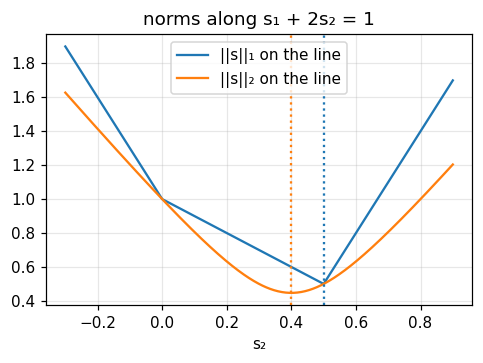


soft threshold S_1(z) = [ 2.  -0.   0.2]   (손계산: (2, 0, 0.2))
ridge z/(1+λ)        = [ 1.5 -0.2  0.6]   (줄이기만 하고 0 을 못 만듦)
RSS 12.0 → 10.5: ΔAIC = -11.35, ΔBIC = -8.75 → 3항
RSS 12.0 → 11.9: ΔAIC = +1.16, ΔBIC = +3.77 → 2항 유지
항 하나가 정당화되는 RSS 감소율 ≈ 1 - exp(-2/n) = 0.019801326693244747


In [3]:
# 손계산 예 1 — s1 + 2 s2 = 1 : ℓ2 최소노름 해 vs ℓ1 최소 해 --------------------------------
Theta1, y1 = np.array([[1.0, 2.0]]), np.array([1.0])
s_l2 = np.linalg.pinv(Theta1) @ y1
print("ℓ2 (pinv):", s_l2, " ||s||2 =", np.linalg.norm(s_l2), " ||s||1 =", np.abs(s_l2).sum())
# ℓ1: min ||s||_1 s.t. Θ s = y  →  선형계획 (s = u - w, u,w ≥ 0, min Σ(u+w))
from scipy.optimize import linprog
res = linprog(c=np.ones(4), A_eq=np.hstack([Theta1, -Theta1]), b_eq=y1, bounds=[(0, None)]*4, method="highs")
s_l1 = res.x[:2] - res.x[2:]
print("ℓ1 (linprog):", s_l1, " ||s||1 =", np.abs(s_l1).sum(), "  (손계산: (0, 0.5))")
if HAVE_CVX:
    s = cp.Variable(2); cp.Problem(cp.Minimize(cp.norm1(s)), [Theta1 @ s == y1]).solve()
    print("ℓ1 (cvxpy):  ", np.round(s.value, 6))
# 기하: 직선 위에서 ||s||_1 = |1-2 s2| + |s2|
s2 = np.linspace(-0.3, 0.9, 400); l1 = np.abs(1 - 2*s2) + np.abs(s2); l2 = np.sqrt((1 - 2*s2)**2 + s2**2)
fig, ax = plt.subplots(figsize=(5, 3.2)); ax.plot(s2, l1, label="||s||₁ on the line"); ax.plot(s2, l2, label="||s||₂ on the line")
ax.axvline(0.5, color="C0", ls=":"); ax.axvline(0.4, color="C1", ls=":"); ax.set_xlabel("s₂"); ax.legend(); ax.set_title("norms along s₁ + 2s₂ = 1"); plt.show()

# 손계산 예 2 — 연임계화 vs ridge ------------------------------------------------------------------
z = np.array([3.0, -0.4, 1.2]); lam = 1.0
print("\nsoft threshold S_1(z) =", soft(z, lam), "  (손계산: (2, 0, 0.2))")
print("ridge z/(1+λ)        =", z/(1+lam), "  (줄이기만 하고 0 을 못 만듦)")

# 손계산 예 3 — AIC 로 항 하나를 더할지 -------------------------------------------------------------
n = 100
for rss2, rss3 in [(12.0, 10.5), (12.0, 11.9)]:
    dA = n*np.log(rss3/rss2) + 2; dB = n*np.log(rss3/rss2) + np.log(n)
    print(f"RSS {rss2} → {rss3}: ΔAIC = {dA:+.2f}, ΔBIC = {dB:+.2f} → {'3항' if dA < 0 else '2항 유지'}")
print("항 하나가 정당화되는 RSS 감소율 ≈ 1 - exp(-2/n) =", 1 - np.exp(-2/n))


## 1. 교재 §3.5 LASSO 예제 재현 — 최소제곱 · LASSO(10-겹 CV, 1-SE) · de-bias · STLSQ 비교

**문제.** $A\in\mathbb{R}^{100\times10}$ 가우시안 난수, 참값 $x=e_3-e_7$, $b=Ax+2\,\mathrm{randn}$. (i) 최소제곱 `pinv(A)@b`, (ii) LASSO (2)를 $\lambda$ 격자에서 풀고 10-겹 교차검증으로 오차 최소 $\lambda$와 1-SE $\lambda$를 정한 해, (iii) 선택된 열로 다시 최소제곱한 de-bias 해, (iv) STLSQ($\lambda=0.5$)의 계수를 **한 표**로 비교한다. 강의노트의 기준치(오차 최소 $\lambda=0.131$, 1-SE $\lambda=0.566$, 1-SE 해 $0.885e_3-0.570e_7$, de-bias $(1.374,-1.054)$)와 대조한다 — 난수가 다르므로 자릿수만 같으면 된다.


In [4]:
# 1-1. 데이터 ------------------------------------------------------------------------------
rng = np.random.default_rng(2)
n, p = 100, 10
A = rng.standard_normal((n, p))
x_true = np.zeros(p); x_true[2] = 1.0; x_true[6] = -1.0          # e3 - e7 (1-base)
b = A @ x_true + 2.0 * rng.standard_normal(n)

# (i) 최소제곱
x_ls = np.linalg.pinv(A) @ b

# (ii) LASSO 경로 + 10-겹 CV
lams = np.logspace(0, -2.5, 60)                                   # 1 → 0.003 (큰 λ 부터)
X_path = lasso_path(A, b, lams)
cv = np.array([kfold_cv(lambda At, bt, lam=lam: lasso_cd(At, bt, lam), lambda m, At: At @ m, A, b, k=10, seed=0) for lam in lams])
cv_mean, cv_se = cv.mean(1), cv.std(1, ddof=1)/np.sqrt(10)
i_min = int(np.argmin(cv_mean)); lam_min = lams[i_min]
i_1se = int(np.where(cv_mean <= cv_mean[i_min] + cv_se[i_min])[0].min())   # 가장 큰 λ (가장 간명) — lams 가 내림차순이라 최소 인덱스
lam_1se = lams[i_1se]
x_lasso_min, x_lasso_1se = X_path[i_min], X_path[i_1se]

# (iii) de-bias: 1-SE 해의 지지집합으로 최소제곱
S = np.flatnonzero(x_lasso_1se); x_debias = np.zeros(p); x_debias[S] = np.linalg.lstsq(A[:, S], b, rcond=None)[0]

# (iv) STLSQ  (A 의 열 척도가 모두 ~1 이므로 정규화 없이 λ=0.5 = 계수 문턱)
x_stlsq = stlsq(A, b, 0.5, normalize=False)

tab = pd.DataFrame({"true": x_true, "least squares": x_ls, f"LASSO λ_min={lam_min:.3f}": x_lasso_min,
                    f"LASSO 1-SE λ={lam_1se:.3f}": x_lasso_1se, "LASSO de-biased": x_debias, "STLSQ λ=0.5": x_stlsq},
                   index=[f"x{j+1}" for j in range(p)])
display(tab.round(3))
print(f"λ_min = {lam_min:.3f} (노트: 0.131),  λ_1SE = {lam_1se:.3f} (노트: 0.566)")
print("0 이 아닌 성분 수:", {c: int(np.sum(np.abs(tab[c]) > 1e-9)) for c in tab.columns})


,true,least squares,LASSO λ_min=0.210,LASSO 1-SE λ=0.677,LASSO de-biased,STLSQ λ=0.5
x1,0,0.114,0,0,0,0
x2,0,-0.075,-0,0,0,0
x3,1,0.802,0.592,0.213,0.767,0.767
x4,0,0.13,0,0,0,0
x5,0,0.241,0,0,0,0
x6,0,-0.149,-0,-0,0,0
x7,-1,-1.101,-0.933,-0.59,-1.081,-1.081
x8,0,0.287,0.073,0,0,0
x9,0,-0.053,-0,-0,0,0
x10,0,0.147,0,0,0,0


λ_min = 0.210 (노트: 0.131),  λ_1SE = 0.677 (노트: 0.566)
0 이 아닌 성분 수: {'true': 2, 'least squares': 10, 'LASSO λ_min=0.210': 3, 'LASSO 1-SE λ=0.677': 2, 'LASSO de-biased': 2, 'STLSQ λ=0.5': 2}


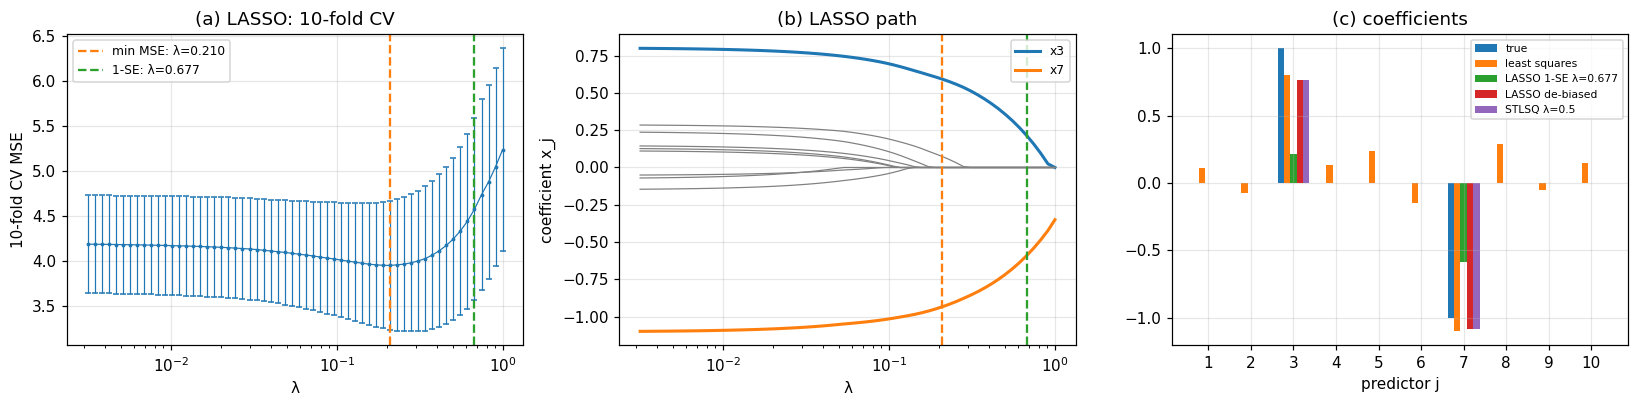

In [5]:
# 1-2. 그림 7 재현: CV 곡선, LASSO 경로, 계수 비교 -----------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].errorbar(lams, cv_mean, yerr=cv_se, fmt=".-", ms=3, lw=0.8, capsize=2); ax[0].set_xscale("log")
ax[0].axvline(lam_min, color="C1", ls="--", label=f"min MSE: λ={lam_min:.3f}"); ax[0].axvline(lam_1se, color="C2", ls="--", label=f"1-SE: λ={lam_1se:.3f}")
ax[0].set_xlabel("λ"); ax[0].set_ylabel("10-fold CV MSE"); ax[0].set_title("(a) LASSO: 10-fold CV"); ax[0].legend(fontsize=8)
for j in range(p): ax[1].plot(lams, X_path[:, j], label=f"x{j+1}" if j in (2, 6) else None, lw=2 if j in (2, 6) else 0.8, color=None if j in (2, 6) else "gray")
ax[1].set_xscale("log"); ax[1].axvline(lam_min, color="C1", ls="--"); ax[1].axvline(lam_1se, color="C2", ls="--")
ax[1].set_xlabel("λ"); ax[1].set_ylabel("coefficient x_j"); ax[1].set_title("(b) LASSO path"); ax[1].legend(fontsize=8)
w = 0.15; idx = np.arange(1, p+1)
for i, c in enumerate(["true", "least squares", f"LASSO 1-SE λ={lam_1se:.3f}", "LASSO de-biased", "STLSQ λ=0.5"]):
    ax[2].bar(idx + (i-2)*w, tab[c], width=w, label=c)
ax[2].set_xticks(idx); ax[2].set_xlabel("predictor j"); ax[2].set_title("(c) coefficients"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()


**결과 해석.**
* 최소제곱은 10개 모두 0이 아니다 — 참값이 0인 8개 항에도 잡음($\sigma=2$, $n=100$이면 표준오차 ≈ 0.2)만큼의 계수가 붙는다.
* LASSO 경로에서 $\lambda$를 줄이면 $x_3$, $x_7$이 **먼저** 살아난다(가장 큰 참 계수). 오차 최소 $\lambda$는 몇 개의 가짜 항을 남기고, **1-SE 규칙**은 더 큰 $\lambda$를 골라 $x_3,x_7$ 두 항만 남긴다 — 단 크기는 수축돼 있다($|x|<1$).
* **de-bias**(선택된 두 열로 다시 최소제곱)는 수축을 되돌려 참값 ±1에 가까운 계수를 준다. **STLSQ**($\lambda=0.5$)는 "최소제곱 → 작은 계수 0 → 남은 열로 다시 최소제곱"이므로 de-bias 해와 **같은 답**이 나온다 — LASSO + de-bias ≈ STLSQ (강의노트 그림 14a).
* 셋 중 무엇을 쓰든 "오차 + 벌점의 균형을 보지 않은 데이터로 정한다"가 공통 — 훈련 오차(λ → 0)로 고르면 최소제곱으로 돌아간다.


## 2. 배포 풀이 `w04_solution_bugs.m` 오류 찾기

**문제.** 배포 풀이(MATLAB, 6개 미니문제)에서 결과를 틀리게 만드는 오류를 찾아 (i) 어느 줄이 어떤 식을 위반하는지, (ii) 수정 코드, (iii) 수정 전후 수치를 기록한다. 파일 머리말에 "의도적 오류 5곳 이상"이라 돼 있다.

**방법.** 2-1에서 원문을 줄 번호와 함께 출력하고, 각 문제의 '검증' 줄이 이상한 값을 내는지 본다. 2-2~2-7은 같은 계산을 Python으로 옮겨 **오류 그대로(before)**와 **수정본(after)**을 나란히 실행해 수치를 비교한다. 찾은 오류 7건(머리말의 "5곳 이상"; 7번은 부호를 고친 뒤에야 드러나는 숨은 오류):

| # | 줄 | 원래 코드 | 위반한 식·개념 | 수정 코드 |
|---|---|---|---|---|
| 1 | L12 | `x = sign(z).*(abs(z) - lam/L)` | 연임계화 $S_t(z)=\mathrm{sign}(z)\max(\lvert z\rvert-t,0)$ [노트 손계산 예 2, B&K (3.15)]: `max(·,0)`이 빠져 작은 성분이 0이 되지 않고 **부호만 뒤집힌 채** 남음 → 희소해가 안 나옴 | `x = sign(z).*max(abs(z) - lam/L, 0)` |
| 2 | L24 | `small = Xi < lambda` | STLSQ 단계 (2) "$\lvert\xi\rvert<\lambda$인 항을 0" [노트 §2.6]: 절댓값이 없어 **음수 계수가 전부** 잘림 (참값 −0.1, −2 모두 음수) | `small = abs(Xi) < lambda` |
| 3 | L38 | `c = Phi \ f` (전체 데이터로 학습) | $k$-겹 CV 정의 [노트 §2.4, B&K §4.6]: 보류 조각을 **빼고** 학습해야 하는데 시험 점을 포함해 학습 → 훈련 오차가 되어 차수가 클수록 유리 | `tr = setdiff(1:100, test); c = Phi(tr,:) \ f(tr)` |
| 4 | L54 | `aic(order) = 2*K + 2*logL` | AIC $=2K-2\log L$ [노트 식 (4), B&K (4.46)]: 부호가 반대라 우도가 **낮을수록** 좋은 모델이 됨 | `aic(order) = 2*K - 2*logL` |
| 5 | L63–66 | `err(i) = mean((A*xl-b).^2)` 로 λ 선택 | 모델 선택은 보지 않은 데이터(CV)로 [노트 §2.4 "훈련 오차로 고르면 언제나 가장 복잡한 모델이 이김"]: 훈련 MSE 최소 = 가장 작은 λ = 최소제곱 | 10-겹 CV MSE(+1-SE 규칙)로 λ 선택 |
| 7 | L51–52 | `rows = T - order` (차수마다 다른 표본 수로 학습) | AIC·BIC 비교는 **같은 데이터**에서 [B&K §4.7, 노트 식 (4)의 $n$]: AR(1)은 99행, AR(3)은 97행이라 $\log L$이 행 수에 비례해 달라져(행 하나당 ≈ 1.9) 고차 모델이 ≈ 2씩 유리 → 부호를 고쳐도 AR(3)을 고름 | 모든 차수를 `k = 4:T` (97행)로 통일 |
| 6 | L73 | `Eext = norm(x1.^2 - Pi*a)/norm(x1.^2)` | 외삽 오차는 시험 구간 $x\in[4,8]$의 라이브러리·참값으로 [노트 §2.3, B&K 그림 4.17]: 훈련 구간을 다시 평가해 보간 오차와 같은 값 | `Eext = norm(fte - Pe*a)/norm(fte)` |


In [6]:
# 2-1. 배포 풀이 원문 (줄 번호) -------------------------------------------------------------------
BUGS_M = NB_DIR / "w04_solution_bugs.m"
if BUGS_M.exists():
    for i, line in enumerate(BUGS_M.read_text(encoding="utf-8", errors="replace").splitlines(), 1):
        print(f"{i:3d}| {line}")
else:
    print("[안내] w04_solution_bugs.m 이 노트북 폴더에 없습니다 — 아래 셀들은 파일 없이도 (Python 재현으로) 실행됩니다.")


  1| % w04_solution_bugs.m — [배포 풀이] 4주차 미니문제 풀이 (MATLAB/Octave, 툴박스·CVX 불필요) — ※ 의도적 오류가 여러 곳(5곳 이상) 포함 ※
  2| % 과제 C(오류 찾기): 결과를 틀리게 만드는 오류를 1건 이상 찾아 (i) 어느 줄이 왜 틀렸는지 (ii) 올바른 코드
  3| % (iii) 수정 전후 수치 비교를 연구노트에 기록하라. 힌트: 각 문제의 '검증' 줄이 이상한 값을 내는지 먼저 확인할 것.
  4| % Python 판(w04_solution_bugs.py)과 같은 오류를 담고 있다.
  5| clear; close all; clc; rng(0);
  6| 
  7| %% 문제 1. 교재 §3.5 LASSO 예제(100×10) 를 근접경사법(ISTA)으로 직접 풀기 — (1/2n)||Ax-b||^2 + lam*||x||_1
  8| A = randn(100, 10); xtrue = zeros(10, 1); xtrue(3) = 1; xtrue(7) = -1; b = A * xtrue + 2 * randn(100, 1);
  9| n = 100; lam = 0.5; L = norm(A)^2 / n; x = zeros(10, 1);
 10| for k = 1:3000
 11|     z = x - (A' * (A * x - b) / n) / L;
 12|     x = sign(z) .* (abs(z) - lam / L);                     % 연 임계화 (soft thresholding)
 13| end
 14| fprintf('[P1] 0 이 아닌 계수 %d개 (참값 2개), x3 = %.3f, x7 = %.3f\n', nnz(abs(x) > 1e-8), x(3), x(7));
 15| fprintf('[P1] 검증: 가장 작은 |x| = %.2e  (희소해라면 정확히 0 인 성분이 있어야 한다)\n', min(abs(x)));
 16| 
 17| %% 문제 2. STLSQ 로 

In [7]:
# 2-2. 오류 1 — P1: ISTA 연임계화에 max(·,0) 누락 (L12) --------------------------------------------------
rngB = np.random.default_rng(7)
A1 = rngB.standard_normal((100, 10)); xt1 = np.zeros(10); xt1[2] = 1; xt1[6] = -1; b1v = A1 @ xt1 + 2*rngB.standard_normal(100)

def ista(A, b, lam, buggy, iters=3000):
    n = len(b); L = np.linalg.norm(A, 2)**2 / n; x = np.zeros(A.shape[1])
    for _ in range(iters):
        z = x - (A.T @ (A @ x - b) / n) / L
        x = np.sign(z) * (np.abs(z) - lam/L) if buggy else np.sign(z) * np.maximum(np.abs(z) - lam/L, 0)   # ← 버그 / 수정
    return x
for tag, bug in [("before (L12 버그)", True), ("after  (수정)", False)]:
    x = ista(A1, b1v, 0.5, bug)
    print(f"[P1] {tag}: 0 아닌 계수 {int(np.sum(np.abs(x) > 1e-8))}개 (참값 2), x3 = {x[2]:.3f}, x7 = {x[6]:.3f}, 가장 작은 |x| = {np.abs(x).min():.2e}")
print("→ 버그판은 |z|<λ/L 인 성분을 0 대신 '부호 반전된 작은 값'으로 남겨 10개 전부 0 이 아니다. 수정판은 정확히 0 인 성분이 생긴다.")


[P1] before (L12 버그): 0 아닌 계수 10개 (참값 2), x3 = 0.290, x7 = -0.107, 가장 작은 |x| = 1.07e-01
[P1] after  (수정): 0 아닌 계수 2개 (참값 2), x3 = 0.281, x7 = -0.114, 가장 작은 |x| = 0.00e+00
→ 버그판은 |z|<λ/L 인 성분을 0 대신 '부호 반전된 작은 값'으로 남겨 10개 전부 0 이 아니다. 수정판은 정확히 0 인 성분이 생긴다.


In [8]:
# 2-3. 오류 2 — P2: STLSQ 임계화에 절댓값 누락 (L24) --------------------------------------------------------
dt = 0.01; t = np.arange(0, 10, dt); Am = np.array([[-0.1, 2.0], [-2.0, -0.1]]); Z = np.zeros((len(t), 2)); Z[0] = [2, 0]
for k in range(len(t)-1):                                   # RK4
    z = Z[k]; k1 = Am@z; k2 = Am@(z+dt/2*k1); k3 = Am@(z+dt/2*k2); k4 = Am@(z+dt*k3); Z[k+1] = z + dt/6*(k1+2*k2+2*k3+k4)
Zn = Z + 0.001*rngB.standard_normal(Z.shape); dZ = np.zeros_like(Zn); dZ[1:-1] = (Zn[2:] - Zn[:-2])/(2*dt); dZ[0] = dZ[1]; dZ[-1] = dZ[-2]
xx, yy = Zn[:, 0], Zn[:, 1]
Theta2 = np.column_stack([np.ones_like(xx), xx, yy, xx**2, xx*yy, yy**2, xx**3, xx**2*yy, xx*yy**2, yy**3])
names2 = ["1", "x", "y", "x^2", "xy", "y^2", "x^3", "x^2y", "xy^2", "y^3"]
def stlsq_file(Theta, dZ, lam, buggy, iters=10):
    Xi = np.linalg.lstsq(Theta, dZ, rcond=None)[0]
    for _ in range(iters):
        small = (Xi < lam) if buggy else (np.abs(Xi) < lam)   # ← 버그 / 수정
        Xi[small] = 0
        for j in range(2):
            big = ~small[:, j]
            if big.any(): Xi[big, j] = np.linalg.lstsq(Theta[:, big], dZ[:, j], rcond=None)[0]
    return Xi
for tag, bug in [("before (L24 버그)", True), ("after  (수정)", False)]:
    Xi = stlsq_file(Theta2, dZ, 0.05, bug)
    print(f"[P2] {tag}: 활성 항 {int(np.sum(Xi != 0))}개 (참값 4); ẋ 의 x, y 계수 = {Xi[1,0]:.3f}, {Xi[2,0]:.3f} (참값 -0.1, 2); ẏ 의 x 계수 = {Xi[1,1]:.3f} (참값 -2)")
print("→ 버그판은 'Xi < λ' 라 음수 계수(-0.1, -2, -0.1)가 모두 0 으로 잘리고 양수 2 만 남는다.")


[P2] before (L24 버그): 활성 항 1개 (참값 4); ẋ 의 x, y 계수 = 0.000, 2.006 (참값 -0.1, 2); ẏ 의 x 계수 = 0.000 (참값 -2)
[P2] after  (수정): 활성 항 4개 (참값 4); ẋ 의 x, y 계수 = -0.100, 2.000 (참값 -0.1, 2); ẏ 의 x 계수 = -2.001 (참값 -2)
→ 버그판은 'Xi < λ' 라 음수 계수(-0.1, -2, -0.1)가 모두 0 으로 잘리고 양수 2 만 남는다.


In [9]:
# 2-4. 오류 3 — P3: 교차검증에서 시험 조각을 포함해 학습 (L38) -------------------------------------------------
x3 = np.linspace(0, 4, 100); f3 = x3**2 + 0.2*rngB.standard_normal(100); idx = rngB.permutation(100); edges = np.round(np.linspace(0, 100, 11)).astype(int)
def cv_degree(buggy):
    cvs = []
    for d in range(1, 11):
        Phi = x3[:, None]**np.arange(d+1); tot = 0.0
        for fo in range(10):
            test = idx[edges[fo]:edges[fo+1]]; tr = np.setdiff1d(np.arange(100), test)
            c = np.linalg.lstsq(Phi, f3, rcond=None)[0] if buggy else np.linalg.lstsq(Phi[tr], f3[tr], rcond=None)[0]   # ← 버그 / 수정
            tot += np.sum((Phi[test] @ c - f3[test])**2)
        cvs.append(tot/100)
    return np.array(cvs)
for tag, bug in [("before (L38 버그)", True), ("after  (수정)", False)]:
    cv3 = cv_degree(bug)
    print(f"[P3] {tag}: 고른 차수 = {int(np.argmin(cv3))+1} (참값 2); 차수 2, 10 의 CV 오차 = {cv3[1]:.4f}, {cv3[9]:.4f}")
print("→ 버그판은 시험 점을 보고 학습한 '훈련 오차' 라 차수가 클수록 작아져 10 을 고른다(단조 감소). 수정판은 차수 2 가 최소.")


[P3] before (L38 버그): 고른 차수 = 10 (참값 2); 차수 2, 10 의 CV 오차 = 0.0305, 0.0294
[P3] after  (수정): 고른 차수 = 2 (참값 2); 차수 2, 10 의 CV 오차 = 0.0329, 0.0420
→ 버그판은 시험 점을 보고 학습한 '훈련 오차' 라 차수가 클수록 작아져 10 을 고른다(단조 감소). 수정판은 차수 2 가 최소.


In [10]:
# 2-5. 오류 4·7 — P4: AIC 부호 (L54) 와 차수마다 다른 표본 수 (L51–52) ----------------------------------------
T, burn = 100, 200; xs = np.zeros(T+burn)
for k in range(2, T+burn): xs[k] = -4 + 0.2*xs[k-1] + 0.5*xs[k-2] + np.sqrt(2)*rngB.standard_normal()
y4 = xs[burn:]
def ar_aic(sign_bug, common_rows):
    out = []
    for order in (1, 2, 3):
        start = 3 if common_rows else order                      # ← 오류 7 수정: 모든 차수를 같은 97행으로
        rows = T - start; Ar = np.column_stack([np.ones(rows)] + [y4[start-1-i:T-1-i] for i in range(order)]); br = y4[start:]
        c = np.linalg.lstsq(Ar, br, rcond=None)[0]; s2 = np.mean((br - Ar@c)**2); logL = -0.5*rows*(np.log(2*np.pi*s2) + 1); K = order + 2
        out.append(2*K + 2*logL if sign_bug else 2*K - 2*logL)   # ← 오류 4 수정: 2K − 2 log L
    return np.array(out)
for tag, sb, cr in [("before (L54 부호 버그)", True, False), ("부호만 수정 (L51 표본 수 불일치 남음)", False, False), ("after  (부호 + 같은 97행)", False, True)]:
    a4 = ar_aic(sb, cr); print(f"[P4] {tag:34s}: AIC = {np.round(a4, 1)} → AR({int(np.argmin(a4))+1}) (참값 AR(2)); ΔAIC(AR3−AR2) = {a4[2]-a4[1]:+.2f}")
print("→ 부호 버그는 우도가 낮을수록 유리해 AR(1). 부호만 고치면 AR(3) 의 행이 2개 적어 logL 이 ≈ 3.8 높게 나와 AR(3). 같은 행으로 맞추면 AR(2)")
print("   (ΔAIC < 2 라도 간명한 AR(2) — 노트 §2.5 규칙). 강의노트 기준 AIC 402.5, 378.5, 377.6 / ΔAIC 0.9 도 같은 데이터로 비교한 값.")


[P4] before (L54 부호 버그)                : AIC = [-336.6 -315.5 -310.4] → AR(1) (참값 AR(2)); ΔAIC(AR3−AR2) = +5.13
[P4] 부호만 수정 (L51 표본 수 불일치 남음)          : AIC = [348.6 331.5 330.4] → AR(3) (참값 AR(2)); ΔAIC(AR3−AR2) = -1.13
[P4] after  (부호 + 같은 97행)              : AIC = [341.3 329.1 330.4] → AR(2) (참값 AR(2)); ΔAIC(AR3−AR2) = +1.27
→ 부호 버그는 우도가 낮을수록 유리해 AR(1). 부호만 고치면 AR(3) 의 행이 2개 적어 logL 이 ≈ 3.8 높게 나와 AR(3). 같은 행으로 맞추면 AR(2)
   (ΔAIC < 2 라도 간명한 AR(2) — 노트 §2.5 규칙). 강의노트 기준 AIC 402.5, 378.5, 377.6 / ΔAIC 0.9 도 같은 데이터로 비교한 값.


In [11]:
# 2-6. 오류 5 — P5: 훈련 MSE 로 λ 선택 (L63–66) --------------------------------------------------------------
lams5 = np.logspace(-3, 0.5, 30)
tr_err = np.array([np.mean((A1 @ ista(A1, b1v, l, False, 1000) - b1v)**2) for l in lams5])
cv5 = np.array([kfold_cv(lambda At, bt, l=l: ista(At, bt, l, False, 1000), lambda m, At: At @ m, A1, b1v, k=10, seed=0) for l in lams5])
cvm, cvse = cv5.mean(1), cv5.std(1, ddof=1)/np.sqrt(10)
i_tr = int(np.argmin(tr_err)); i_cv = int(np.argmin(cvm)); i_1se = int(np.where(cvm <= cvm[i_cv] + cvse[i_cv])[0].max())   # lams 오름차순 → 가장 큰 λ
nz = lambda l: int(np.sum(np.abs(ista(A1, b1v, l, False, 1000)) > 1e-8))
print(f"[P5] before (훈련 MSE): λ = {lams5[i_tr]:.4f} (훑은 범위의 최소값 = 끝), 0 아닌 계수 {nz(lams5[i_tr])}개 (참값 2)")
print(f"[P5] after  (10-겹 CV 최소): λ = {lams5[i_cv]:.4f}, 0 아닌 계수 {nz(lams5[i_cv])}개;  1-SE: λ = {lams5[i_1se]:.4f}, 0 아닌 계수 {nz(lams5[i_1se])}개")
print("→ 훈련 MSE 는 λ 가 작을수록 단조 감소하므로 언제나 격자의 끝(최소 λ = 최소제곱)을 고른다. 파일의 '검증' 줄이 바로 이 증상을 말한다.")


[P5] before (훈련 MSE): λ = 0.0010 (훑은 범위의 최소값 = 끝), 0 아닌 계수 10개 (참값 2)
[P5] after  (10-겹 CV 최소): λ = 0.1964, 0 아닌 계수 5개;  1-SE: λ = 3.1623, 0 아닌 계수 0개
→ 훈련 MSE 는 λ 가 작을수록 단조 감소하므로 언제나 격자의 끝(최소 λ = 최소제곱)을 고른다. 파일의 '검증' 줄이 바로 이 증상을 말한다.


In [12]:
# 2-7. 오류 6 — P6: 외삽 오차를 훈련 구간에서 계산 (L73) -------------------------------------------------------
x2 = np.linspace(0, 8, 200); x1, xe = x2[:100], x2[100:]; ftr = x1**2 + 0.1*rngB.standard_normal(100); fte = xe**2
Pi, Pe = x1[:, None]**np.arange(20), xe[:, None]**np.arange(20); a6 = np.linalg.pinv(Pi) @ ftr
Eint = np.linalg.norm(x1**2 - Pi@a6)/np.linalg.norm(x1**2)
Eext_bug = np.linalg.norm(x1**2 - Pi@a6)/np.linalg.norm(x1**2)          # ← 버그: 훈련 구간 재평가
Eext_fix = np.linalg.norm(fte - Pe@a6)/np.linalg.norm(fte)              # ← 수정: 시험 구간 x∈[4,8]
print(f"[P6] 보간오차 {Eint:.4f};  외삽오차 before = {Eext_bug:.4f} (보간과 동일 — 틀림),  after = {Eext_fix:.3e}")
print("→ 20항 다항식은 훈련 구간 밖에서 발산한다 (노트 §2.3: 20항 외삽 오차 ~1e9). 버그판은 그 사실을 숨긴다.")


[P6] 보간오차 0.0054;  외삽오차 before = 0.0054 (보간과 동일 — 틀림),  after = 1.358e+09
→ 20항 다항식은 훈련 구간 밖에서 발산한다 (노트 §2.3: 20항 외삽 오차 ~1e9). 버그판은 그 사실을 숨긴다.


**문제 2 정리.** 일곱 오류는 모두 4주차의 핵심 식·원리 한 줄씩에 대응한다: 연임계화의 $\max(\cdot,0)$(1), 임계화의 절댓값(2), 교차검증의 "보류 조각은 학습에서 뺀다"(3), AIC의 부호(4), "모델 선택은 보지 않은 데이터로"(5), "외삽은 시험 구간에서"(6), "정보기준은 같은 데이터로 비교"(7). 파일의 '검증' 줄이 각각의 증상(0이 정확히 없음 / 음수 계수 소실 / 차수 10 선택 / 데이터항 방향 / λ가 격자 끝 / 외삽 = 보간)을 가리키고, 7번은 4번을 고친 뒤 AR(3)이 계속 선택되는 것을 추적해 찾았다. Python 재현은 난수가 MATLAB과 달라 수치는 다르지만 수정 전후의 **정성적 차이**(희소성 유무, 선택 차수, 부호)는 같다.


## 3. 개인 탐구문제 — CNT 공진기 FRC 데이터에서 운동방정식의 희소 복원 (SINDy/STLSQ)

### 3-0. 데이터와 목표
Part A(W02) D와 같은 파일 `Q_20_DC_1_AC_0.19_Ω_0.7_HBM_coeffs_branch01/02.csv`를 쓴다. 각 연속점의 HBM 계수 $(a_0,a_k,b_k)$로 한 주기의 $x(t)$를 재구성하면 **미분도 해석적으로** 얻어진다(미분을 수치로 하지 않아도 됨 — 4주차의 "잡음이 커지면 미분이 먼저 무너진다"를 피하는 데이터):
$$x=a_0+\sum_k(a_k\cos k\Omega_dt+b_k\sin k\Omega_dt),\quad \dot x=\sum_k k\Omega_d(-a_k\sin+b_k\cos),\quad \ddot x=-\sum_k(k\Omega_d)^2(a_k\cos+b_k\sin),\qquad \Omega_d=\Omega\sqrt{\omega_1^2}.$$

**참 모델** (시뮬레이션 코드 `main_0819.jl`의 무차원 운동방정식; Physica E 2015 식 6·7a):
$$(1+\alpha_I x^2)\ddot x + c\dot x + \omega_1^2 x + \alpha_G x^3 + \alpha_I x\dot x^2 = d_2\gamma_2\frac{V(t)^2}{(y_{PI}-x)^{m}},\qquad V=V_{DC}+V_{AC}\cos\Omega_dt,\ c=3.516/Q$$
$Q=20,\ \omega_1^2=12.362,\ \alpha_G=0.984,\ \alpha_I=0.112,\ d_2\gamma_2=0.2884,\ m=0.68,\ y_{PI}=0.5,\ V_{DC}=1,\ V_{AC}=0.19$.
$\ddot x$를 좌변에 홀로 두면 계수에 선형인 꼴이 된다:
$$\ddot x = -c\,\dot x-\omega_1^2 x-\alpha_G x^3-\alpha_I x\dot x^2-\alpha_I x^2\ddot x + d_2\gamma_2\,\frac{V^2}{(y_{PI}-x)^{0.68}}\quad\Rightarrow\quad \ddot x=\Theta(x,\dot x,\ddot x,t)\,\xi,\ \ \text{참 }\xi\text{는 6개 항만 }\ne0.$$

**목표.** 참 모델을 *모르는 척* 후보항 라이브러리 $\Theta$(16열: 다항·속도·관성 결합·정전기력 후보 여러 지수)를 만들고 STLSQ로 희소한 $\xi$를 찾는다. (i) $\lambda$에 따른 **활성 항 수–검증오차 곡선**(5-겹 CV)과 AIC로 $\lambda$를 고르고, (ii) 복원된 계수를 참값과 대조하고, (iii) main 가지로 학습한 모델을 **isola 가지(풀인 근처, 간극 0.006)로 외삽**해 §4.5의 "간명한 모델만 외삽에서 산다"를 확인한다.

**데이터 행렬.** 연속점을 10개마다 하나, 한 주기를 64점으로 → main 320점 × 64 = 20,480행, isola 226 × 64 = 14,400행. 열은 아래 16개 후보항.


In [13]:
# 3-1. HBM 계수 → x, ẋ, ẍ 시계열, 후보항 라이브러리 Θ --------------------------------------------------
case = "Q_20_DC_1_AC_0.19_Ω_0.7"
b1 = pd.read_csv(DATA_DIR / f"{case}_HBM_coeffs_branch01.csv"); b2 = pd.read_csv(DATA_DIR / f"{case}_HBM_coeffs_branch02.csv")
hbm_cols = [c for c in b1.columns if c.startswith("hbm_")]; NH = (len(hbm_cols)-1)//2

P = dict(Q=20.0, w1sq=12.362, aG=0.984, aI=0.112, d2g2=0.028*10.3, m=0.68, yPI=0.5, VDC=1.0, VAC=0.19)
P["c"] = 3.516/P["Q"]

def time_series(df, Nt=64, step=10):
    # 각 연속점의 한 주기를 Nt 점으로 재구성. 반환 열: x, xdot, xddot, V^2, Omega, point index
    df = df.iloc[::step]; tau = np.linspace(0, 2*np.pi, Nt, endpoint=False); out = []
    for C, Om, pi in zip(df[hbm_cols].to_numpy(), df.Omega.to_numpy(), df.point_index.to_numpy()):
        Od = Om*np.sqrt(P["w1sq"]); x = np.full(Nt, C[0]); v = np.zeros(Nt); a = np.zeros(Nt)
        for k in range(1, NH+1):
            ak, bk = C[2*k-1], C[2*k]; ck, sk = np.cos(k*tau), np.sin(k*tau)
            x += ak*ck + bk*sk; v += k*Od*(-ak*sk + bk*ck); a += -(k*Od)**2*(ak*ck + bk*sk)
        V2 = (P["VDC"] + P["VAC"]*np.cos(tau))**2
        out.append(np.column_stack([x, v, a, V2, np.full(Nt, Om), np.full(Nt, pi)]))
    return np.vstack(out)

D_main, D_iso = time_series(b1), time_series(b2)
print("main rows", len(D_main), "| isola rows", len(D_iso), "| gap min: main", (P["yPI"]-D_main[:,0]).min().round(4), " isola", (P["yPI"]-D_iso[:,0]).min().round(4))

LIB_NAMES = ["1", "x", "x^2", "x^3", "x^4", "x^5", "xdot", "xdot^2", "x*xdot^2", "x^2*xddot",
             "V^2", "V^2/g^0.5", "V^2/g^0.68", "V^2/g^1", "V^2/g^2", "1/g^0.68"]        # g = y_PI - x
def library(D):
    x, v, a, V2 = D[:, 0], D[:, 1], D[:, 2], D[:, 3]; g = P["yPI"] - x
    Th = np.column_stack([np.ones_like(x), x, x**2, x**3, x**4, x**5, v, v**2, x*v**2, x**2*a,
                          V2, V2/g**0.5, V2/g**0.68, V2/g, V2/g**2, 1/g**0.68])
    return Th, a                                                   # 목표 y = ẍ
Th_m, y_m = library(D_main); Th_i, y_i = library(D_iso)

XI_TRUE = dict(zip(LIB_NAMES, np.zeros(len(LIB_NAMES))))
XI_TRUE.update({"x": -P["w1sq"], "x^3": -P["aG"], "xdot": -P["c"], "x*xdot^2": -P["aI"], "x^2*xddot": -P["aI"], "V^2/g^0.68": P["d2g2"]})
xi_true = np.array([XI_TRUE[n] for n in LIB_NAMES])

# 데이터가 참 모델을 얼마나 만족하는가 (HBM 13차 절단의 점별 잔차)
for nm, Th, y in [("main", Th_m, y_m), ("isola", Th_i, y_i)]:
    print(f"{nm}: 참 모델의 점별 잔차 ||ẍ - Θξ_true|| / ||ẍ|| = {np.linalg.norm(y - Th@xi_true)/np.linalg.norm(y):.2e},  cond(Θ_normalized) = {np.linalg.cond(Th/np.linalg.norm(Th,axis=0)):.1e}")


main rows 20416 | isola rows 14464 | gap min: main 0.0799  isola 0.0057
main: 참 모델의 점별 잔차 ||ẍ - Θξ_true|| / ||ẍ|| = 2.65e-06,  cond(Θ_normalized) = 9.0e+04
isola: 참 모델의 점별 잔차 ||ẍ - Θξ_true|| / ||ẍ|| = 1.54e-02,  cond(Θ_normalized) = 5.0e+03


> 위 잔차가 말하는 것: main 가지의 HBM 해는 13차 조화로 운동방정식을 $10^{-6}$ 수준까지 점별로 만족하지만, isola는 간극이 0.006까지 줄어 $1/(y_{PI}-x)^{0.68}$이 거의 특이점처럼 거동하므로 13차 조화로는 점별 잔차가 1.5 % 남는다(Galerkin 투영은 13차까지만 0으로 만든다). 즉 **isola 데이터는 "참 모델 + 1.5 % 구조적 오차"**이고, 이것이 아래 결과를 가른다.


### 3-2. main 가지 — $\lambda$ 훑기: 활성 항 수–검증오차 곡선, CV·AIC 선택


AIC 최소 λ = 0.0010 (K=6),  CV 최소 λ = 0.0076 (K=6)
6항 평탄부: λ ∈ [0.0010, 0.4427],  그 구간의 검증오차 = 3.13e-03,  계수 오차 = 6.40e-09


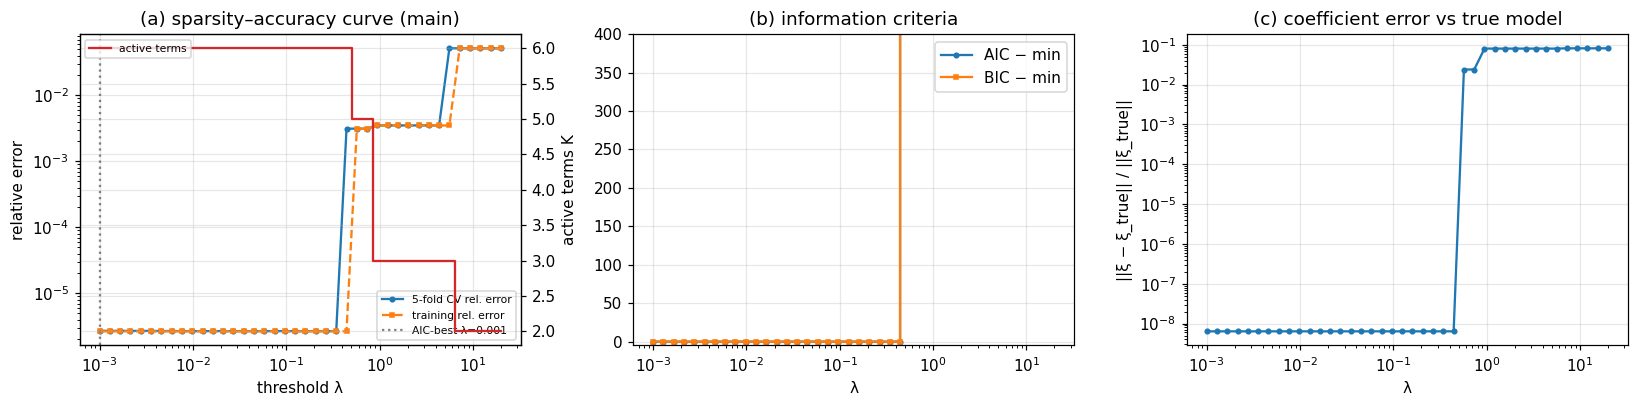

In [14]:
# 3-2. λ sweep on main branch -------------------------------------------------------------------------
lams3 = np.logspace(-3, 1.3, 40)
def sweep(Th, y, lams, k=5, seed=0):
    rows = []
    for lam in lams:
        xi = stlsq(Th, y, lam); K = int(np.sum(xi != 0))
        rss = np.sum((y - Th@xi)**2); aic, bic = aic_bic(max(rss, 1e-300), len(y), K)
        cvm = kfold_cv(lambda At, bt, lam=lam: stlsq(At, bt, lam), lambda m, At: At @ m, Th, y, k=k, seed=seed)
        rows.append(dict(lam=lam, K=K, train_rel=np.sqrt(rss)/np.linalg.norm(y), cv_rel=np.sqrt(cvm.mean())/np.sqrt(np.mean(y**2)), AIC=aic, BIC=bic,
                         coef_err=np.linalg.norm(xi - xi_true)/np.linalg.norm(xi_true)))
    return pd.DataFrame(rows)
SW = sweep(Th_m, y_m, lams3)
lam_aic = SW.lam[SW.AIC.idxmin()]; lam_cv = SW.lam[SW.cv_rel.idxmin()]
plateau = SW[(SW.K == 6)]
print(f"AIC 최소 λ = {lam_aic:.4f} (K={int(SW.K[SW.AIC.idxmin()])}),  CV 최소 λ = {lam_cv:.4f} (K={int(SW.K[SW.cv_rel.idxmin()])})")
print(f"6항 평탄부: λ ∈ [{plateau.lam.min():.4f}, {plateau.lam.max():.4f}],  그 구간의 검증오차 = {plateau.cv_rel.max():.2e},  계수 오차 = {plateau.coef_err.max():.2e}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].semilogx(SW.lam, SW.cv_rel+1e-16, "o-", ms=3, label="5-fold CV rel. error"); ax[0].semilogx(SW.lam, SW.train_rel+1e-16, "s--", ms=3, label="training rel. error")
ax[0].set_yscale("log"); ax2 = ax[0].twinx(); ax2.step(SW.lam, SW.K, where="mid", color="C3", label="active terms"); ax2.set_ylabel("active terms K")
ax[0].axvline(lam_aic, color="gray", ls=":", label=f"AIC-best λ={lam_aic:.3g}"); ax[0].set_xlabel("threshold λ"); ax[0].set_ylabel("relative error"); ax[0].set_title("(a) sparsity–accuracy curve (main)"); ax[0].legend(fontsize=7, loc="lower right"); ax2.legend(fontsize=7, loc="upper left")
ax[1].semilogx(SW.lam, SW.AIC - SW.AIC.min(), "o-", ms=3, label="AIC − min"); ax[1].semilogx(SW.lam, SW.BIC - SW.BIC.min(), "s-", ms=3, label="BIC − min"); ax[1].set_xlabel("λ"); ax[1].set_title("(b) information criteria"); ax[1].legend(); ax[1].set_ylim(-5, 400)
ax[2].semilogx(SW.lam, SW.coef_err, "o-", ms=3); ax[2].set_yscale("log"); ax[2].set_xlabel("λ"); ax[2].set_ylabel("||ξ − ξ_true|| / ||ξ_true||"); ax[2].set_title("(c) coefficient error vs true model")
plt.tight_layout(); plt.show()


In [15]:
# 3-3. 복원된 계수 vs 참값 (main): 최소제곱 · STLSQ(평탄부) · STLSQ(큰 λ) ---------------------------------
lam_pick = float(np.sqrt(plateau.lam.min()*plateau.lam.max()))     # 평탄부 한가운데(기하평균)
xi_ls   = np.linalg.lstsq(Th_m, y_m, rcond=None)[0]
xi_pl   = stlsq(Th_m, y_m, lam_pick)
xi_big  = stlsq(Th_m, y_m, 2.0)
tab3 = pd.DataFrame({"true": xi_true, "least squares": xi_ls, f"STLSQ λ={lam_pick:.3g} (plateau)": xi_pl, "STLSQ λ=2": xi_big}, index=LIB_NAMES)
display(tab3.round(4).style.apply(lambda s: ["font-weight:bold" if XI_TRUE[n] != 0 else "" for n in s.index], axis=0))
for c in tab3.columns[1:]:
    xi = tab3[c].to_numpy(); print(f"{c:28s} 활성 {int(np.sum(xi!=0)):2d}항, train rel.err {np.linalg.norm(y_m-Th_m@xi)/np.linalg.norm(y_m):.2e}, isola 외삽 rel.err {np.linalg.norm(y_i-Th_i@xi)/np.linalg.norm(y_i):.2e}")


,true,least squares,STLSQ λ=0.021 (plateau),STLSQ λ=2
1,0.000000,-0.000000,0.000000,0.000000
x,-12.362000,-12.362000,-12.362000,-12.376500
x^2,0.000000,-0.000000,0.000000,0.000000
x^3,-0.984000,-0.984000,-0.984000,0.000000
x^4,0.000000,-0.000300,0.000000,0.000000
x^5,0.000000,-0.000900,0.000000,0.000000
xdot,-0.175800,-0.175800,-0.175800,-0.175800
xdot^2,0.000000,-0.000000,0.000000,0.000000
x*xdot^2,-0.112000,-0.112000,-0.112000,0.000000
x^2*xddot,-0.112000,-0.112000,-0.112000,0.000000


least squares                활성 16항, train rel.err 2.65e-06, isola 외삽 rel.err 1.54e-02
STLSQ λ=0.021 (plateau)      활성  6항, train rel.err 2.65e-06, isola 외삽 rel.err 1.54e-02
STLSQ λ=2                    활성  3항, train rel.err 3.49e-03, isola 외삽 rel.err 2.93e-02


**main 가지 결과 해석.**
* 최소제곱은 16개 열 전부에 계수를 흩뿌린다. 후보 라이브러리에 $V^2/g^{0.5},\ V^2/g^{0.68},\ V^2/g^{1}$처럼 서로 거의 평행한 열이 있어(조건수 $\sim10^5$) 참 계수 0.288이 여러 열로 나뉘어 들어간다 — 4주차 §2.2의 "pinv·backslash는 실현마다 흔들린다"의 결정론적 판.
* STLSQ는 넓은 $\lambda$ 평탄부($10^{-3}\le\lambda\lesssim0.44$, 격자 40점 중 25점)에서 **정확히 6항**을 잡고, 계수가 참값과 $10^{-8}$ 이내로 일치한다($\omega_1^2=12.362$, $\alpha_G=0.984$, $c=0.1758$, $\alpha_I=0.112$ 두 번, $d_2\gamma_2=0.2884$). 지수 후보 0.5, 1, 2는 모두 버려지고 **0.68만 살아남는다** — 라이브러리에 참 함수형이 들어 있으면 임계화가 평행한 가짜 열을 제거한다.
* AIC 최소와 CV 최소가 모두 평탄부 안에 있다(강의노트 그림 14c와 같은 구조: 평탄부 시작 = AIC 최소). $\lambda\approx0.5$에서 가장 작은 정규화 계수인 $\alpha_I x\dot x^2$가 먼저 잘려 5항(검증오차 0.3 %), $\lambda\ge1$이면 $\alpha_I x^2\ddot x$와 $\alpha_G x^3$까지 잘려 3항(0.35 %), $\lambda\gtrsim7$이면 감쇠항까지 잘려 2항(5 %) — 손계산 예 3의 "RSS를 2 % 이상 줄이는 항만 정당화" 논리로 AIC가 이를 판정한다.
* 외삽: 평탄부 모델을 isola(풀인 근처)에 적용하면 오차 1.5 % = isola 데이터 자체의 HBM 절단 잔차. 즉 **간명한 6항 모델은 훈련 구간 밖(간극 0.08 → 0.006)에서도 데이터가 허용하는 한계까지 맞는다.** 16항 최소제곱 모델의 외삽 오차와 비교해 보라(§4.5 그림 11c의 논리).


### 3-4. isola 가지 — 구조적 오차 1.5 %가 있을 때 희소회귀는 어떻게 되는가


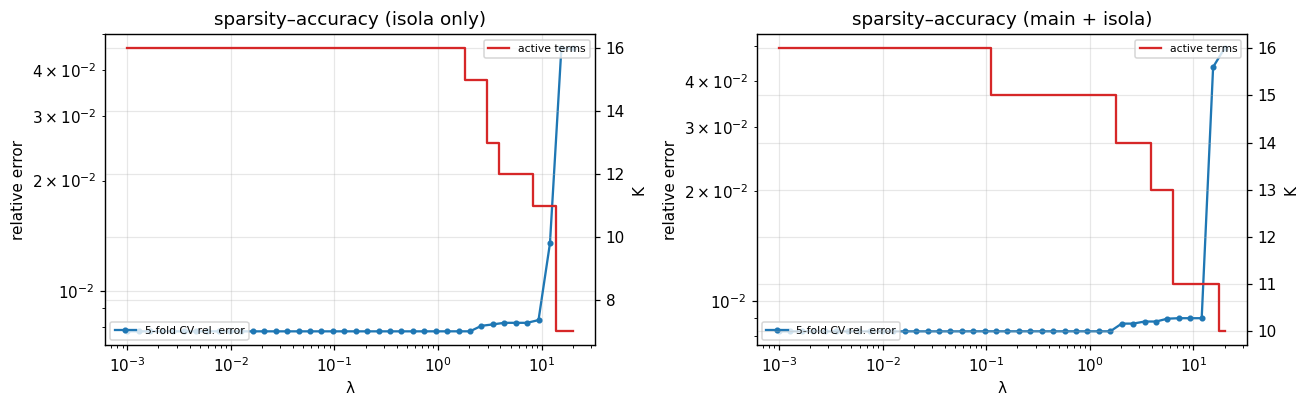

,true,STLSQ main (λ=0.021),STLSQ isola (λ=0.021),STLSQ main+isola (λ=0.021)
1,0,0,0.013,-0.025
x,-12.36,-12.36,-11.94,-12.29
x^2,0,0,-0.621,-1.044
x^3,-0.984,-0.984,38.81,36.8
x^4,0,0,-2.045,-1.273
x^5,0,0,2.64,2.843
xdot,-0.176,-0.176,-0.142,-0.161
xdot^2,0,0,0.024,0.001
x*xdot^2,-0.112,-0.112,-0.265,-0.093
x^2*xddot,-0.112,-0.112,3.438,3.099


isola 만으로는 어떤 λ 에서도 6항 평탄부가 생기지 않음: K=6 인 λ 개수 = 0 | main+isola: 0


In [16]:
# 3-4. 같은 λ sweep on isola, and on main+isola ------------------------------------------------------------
SWi = sweep(Th_i, y_i, lams3)
Th_b, y_b = np.vstack([Th_m, Th_i]), np.concatenate([y_m, y_i]); SWb = sweep(Th_b, y_b, lams3)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for a_, (nm, S) in zip(ax, [("isola only", SWi), ("main + isola", SWb)]):
    a_.semilogx(S.lam, S.cv_rel, "o-", ms=3, label="5-fold CV rel. error"); a_.set_yscale("log"); a_.set_xlabel("λ"); a_.set_ylabel("relative error")
    a2 = a_.twinx(); a2.step(S.lam, S.K, where="mid", color="C3", label="active terms"); a2.set_ylabel("K"); a_.set_title(f"sparsity–accuracy ({nm})"); a_.legend(fontsize=7, loc="lower left"); a2.legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()
xi_i = stlsq(Th_i, y_i, lam_pick); xi_b = stlsq(Th_b, y_b, lam_pick)
tab4 = pd.DataFrame({"true": xi_true, f"STLSQ main (λ={lam_pick:.3g})": xi_pl, f"STLSQ isola (λ={lam_pick:.3g})": xi_i, f"STLSQ main+isola (λ={lam_pick:.3g})": xi_b}, index=LIB_NAMES)
display(tab4.round(3))
print("isola 만으로는 어떤 λ 에서도 6항 평탄부가 생기지 않음:", "K=6 인 λ 개수 =", int((SWi.K == 6).sum()), "| main+isola:", int((SWb.K == 6).sum()))


**isola 결과 해석.**
* isola 데이터로는 $\lambda$를 아무리 훑어도 6항 평탄부가 생기지 않고 11–16항이 남으며, 살아남은 계수도 참값과 다르다($x^3$에 30 이상, $V^2/g^{0.5}$와 $V^2/g^{0.68}$가 서로 반대 부호로 큰 값). 검증오차는 0.8 % 아래로 내려가지 않는다.
* 원인은 잡음이 아니라 **데이터가 참 모델을 점별로 1.5 %밖에 못 맞추는 구조적 오차**(13차 조화 절단)다. 4주차 노트의 "잡음이 커지면 미분이 먼저 무너진다"의 다른 얼굴: 여기서는 미분은 해석적이라 정확하지만, 주기해 자체가 저차 조화 공간에 투영된 근사해라서 $\ddot x$의 고조파 성분이 빠져 있고, 희소회귀는 그 빠진 부분을 가짜 항들의 조합으로 메우려 한다.
* main+isola를 합쳐도 isola의 구조적 오차가 섞여 평탄부가 사라진다. 교훈: **희소회귀의 전제는 "데이터가 어떤 희소 모델을 (잡음 수준까지) 만족한다"이고, 그 수준보다 큰 모델 오차가 있으면 $\lambda$ 선택으로는 구제되지 않는다.** 해결은 데이터 쪽(isola는 $N_H$를 늘려 다시 계산)이지 회귀 쪽이 아니다.


### 3-5. 잡음 실험 — main 가지에 측정 잡음을 넣으면 평탄부는 어디까지 버티는가
실측이라면 $x$에 잡음이 들어오고 미분은 수치로 해야 한다. 여기서는 (i) $x,\dot x,\ddot x$ 각각에 상대 잡음 $\eta$를 더한 경우와 (ii) $x$에만 잡음을 넣고 $\dot x,\ddot x$를 **중앙차분**으로 구한 경우를 비교한다(강의노트 진동자 예제의 설정).


In [17]:
# 3-5. noise experiment ---------------------------------------------------------------------------------
rngN = np.random.default_rng(0)
def with_noise(D, eta, numeric_diff=False, Nt=64):
    Dn = D.copy(); x, v, a = D[:, 0], D[:, 1], D[:, 2]
    Dn[:, 0] = x + eta*np.std(x)*rngN.standard_normal(len(x))
    if numeric_diff:                       # 스냅샷마다 주기적 중앙차분 (Δt = T/Nt, T = 2π/Ω_d)
        for s in range(0, len(D), Nt):
            xs = Dn[s:s+Nt, 0]; Od = D[s, 4]*np.sqrt(P["w1sq"]); dt = 2*np.pi/Od/Nt
            Dn[s:s+Nt, 1] = (np.roll(xs, -1) - np.roll(xs, 1))/(2*dt)
            Dn[s:s+Nt, 2] = (np.roll(xs, -1) - 2*xs + np.roll(xs, 1))/dt**2
    else:
        Dn[:, 1] = v + eta*np.std(v)*rngN.standard_normal(len(v)); Dn[:, 2] = a + eta*np.std(a)*rngN.standard_normal(len(a))
    return Dn
rows = []
for eta in [0.0, 1e-4, 1e-3, 1e-2]:
    for nd in [False, True]:
        Dn = with_noise(D_main, eta, numeric_diff=nd); Thn, yn = library(Dn); S = sweep(Thn, yn, lams3, k=5)
        pl = S[S.K == 6]; bA = S.loc[S.AIC.idxmin()]; bB = S.loc[S.BIC.idxmin()]; bC = S.loc[S.cv_rel.idxmin()]
        rows.append(dict(eta=eta, derivatives="central diff" if nd else "analytic+noise", n_lambda_K6=len(pl),
                         plateau_coef_err=(pl.coef_err.max() if len(pl) else np.nan),
                         K_at_AIC=int(bA.K), K_at_BIC=int(bB.K), K_at_CV=int(bC.K), coef_err_BIC=bB.coef_err, cv_err_BIC=bB.cv_rel))
display(pd.DataFrame(rows))
print("읽는 법: n_lambda_K6 = 6항 평탄부에 속하는 λ 격자점 수(0 이면 참 모델이 복원되지 않음), plateau_coef_err = 그 평탄부 모델의 계수 오차,\n        K_at_AIC/BIC/CV = 각 기준이 고른 모델의 항 수 (참값 6).")


,eta,derivatives,n_lambda_K6,plateau_coef_err,K_at_AIC,K_at_BIC,K_at_CV,coef_err_BIC,cv_err_BIC
0,0,analytic+noise,25,6.398e-09,6,6,6,6.398e-09,2.701e-06
1,0,central diff,3,0.0995,16,16,16,0.03364,0.0001132
2,0.0001,analytic+noise,5,8.77e-05,9,6,9,8.77e-05,0.0001436
3,0.0001,central diff,0,NaN,14,14,14,4.438,0.04078
4,0.001,analytic+noise,4,0.1024,13,9,12,0.009242,0.001441
5,0.001,central diff,0,NaN,13,13,14,22.88,0.3574
6,0.01,analytic+noise,0,NaN,14,12,15,1.184,0.01448
7,0.01,central diff,0,NaN,11,11,13,30.89,0.928


읽는 법: n_lambda_K6 = 6항 평탄부에 속하는 λ 격자점 수(0 이면 참 모델이 복원되지 않음), plateau_coef_err = 그 평탄부 모델의 계수 오차,
        K_at_AIC/BIC/CV = 각 기준이 고른 모델의 항 수 (참값 6).


**잡음 실험 해석.**
* 해석적 미분 + 잡음: $\eta=10^{-4}$에서는 6항 평탄부가 좁아지지만(격자점 25 → 5) 남아 있고 그 모델의 계수 오차는 $10^{-4}$; **BIC는 6항을 고르지만 AIC·CV는 9항**을 고른다. $\eta=10^{-3}$이면 평탄부 모델의 계수 오차가 10 %로 커지고 BIC도 9항. $n=20{,}000$행이라 AIC 벌점 $2K$는 $n\ln(\mathrm{RSS}/n)$에 비해 너무 작아 가짜 항을 허용하고, BIC 벌점 $K\ln n\approx10K$가 그나마 버틴다 — 노트 §2.5 "BIC가 더 간명한 쪽"의 수치 확인. 잡음이 있을 때는 CV 최소보다 **1-SE 규칙이나 BIC**, 또는 평탄부의 큰 $\lambda$ 끝을 고르는 것이 맞다.
* 중앙차분: $\eta=0$에서도 64점/주기의 차분 오차($O(\Delta t^2)$)가 $\ddot x$에 0.01 % 들어가 평탄부가 3점으로 줄고 계수 오차 10 %; $\eta=10^{-4}$만 돼도 평탄부가 사라지고 $\eta=10^{-2}$면 계수 오차 30배 — 잡음이 $1/\Delta t^2$배 증폭돼 $\ddot x$가 먼저 무너진다. 4주차 노트의 마지막 문장("잡음이 커지면 미분이 먼저 무너짐")의 수치 확인이며, 7주차 SINDy에서 미분 전 평활(총변동 정칙화 미분 등)이 필요한 이유다.


### 3-6. 요약
| 항목 | 결과 |
|---|---|
| 데이터 | CNT 공진기 HBM 주기해(V_AC = 0.19) → $x,\dot x,\ddot x$ 해석적 재구성; main 20,480행, isola 14,400행 |
| 라이브러리 | 16열: $1,x,\dots,x^5,\dot x,\dot x^2,x\dot x^2,x^2\ddot x,V^2,V^2/g^{0.5,0.68,1,2},1/g^{0.68}$ (조건수 $\sim10^5$, 평행한 후보 포함) |
| main 복원 | STLSQ 평탄부 $10^{-3}\le\lambda\lesssim0.44$에서 정확히 6항, 계수 오차 $10^{-8}$; 지수 후보 중 0.68만 생존; AIC·CV 최소가 평탄부 안 |
| 외삽 | 6항 모델 → isola(간극 0.006) 오차 1.5 % = 데이터의 HBM 절단 잔차; 간명한 모델이 외삽에서 산다 |
| isola 복원 | 구조적 오차 1.5 % 때문에 평탄부 없음·11–16항·계수 오류 — 희소회귀는 모델 오차를 $\lambda$로 구제하지 못함 |
| 잡음 | 해석적 미분이면 $\eta=10^{-4}$까지 평탄부 유지(BIC가 6항, AIC·CV는 과선택); 중앙차분은 $\eta=10^{-4}$에서 이미 $\ddot x$가 무너짐 |



## AI 사용 명세

사용 도구: Claude (Anthropic). 노트북 구성·코드 초안·문제 3의 라이브러리 설계 논의에 사용했고, 아래는 실제로 던진 질문의 로그와 교재(식 번호)와 대조해 확인·수정한 지점이다. 코드는 모두 직접 실행해 수치를 확인했다.

### 1. 질문 로그 — 노트북 구성

| # | 질문 | 교재와 대조해 확인·수정한 지점 |
|---|---|---|
| 1 | W04 과제 1·2·3을 Part A와 같은 구성(주차 정리 → 문제 → 코드 → 결과)의 .ipynb로 만들되, 개인 탐구는 내 데이터(CNT FRC)로. | 과제 요구사항(3문항 + AI 사용 명세)을 강의노트 14쪽과 대조. LASSO 규약 $\frac1{2n}\|Ax-b\|^2+\lambda\|x\|_1$ [B&K (3.15), 노트 식 (2)]를 좌표하강 구현에 그대로 사용. |
| 2 | cvxpy·scikit-learn이 없는 환경에서도 돌게 할 수 있나? | LASSO는 좌표하강, ℓ₁ 최소화는 `scipy.optimize.linprog`(변수 분리 $s=u-w$), STLSQ·k-겹 CV·AIC/BIC는 numpy로 직접 구현. cvxpy가 있으면 손계산 예 1 검산에만 추가. |
| 3 | Part A(SVD)와 같은 데이터를 쓰면 두 과제가 어떻게 이어지나? | 같은 HBM 주기해에서 Part A는 "파형이 몇 차원인가"(POD 모드·에너지), Part B는 "그 파형을 낳는 방정식이 몇 항인가"(후보 함수·CV/AIC) — 둘 다 "기저에 투영하고 큰 계수만 남긴다"는 같은 원리임을 3-6에 정리. |

### 2. 질문 로그 — 문제별 세부 질문과 확인 지점

**문제 1 (LASSO 예제 재현)**

| # | 질문 | 확인·수정한 지점 |
|---|---|---|
| 1-1 | 좌표하강에서 각 성분의 갱신식은 어떻게 유도되나? | 다른 성분을 고정하고 $x_j$에 대해 (2)를 미분하면 1차원 LASSO → 연임계화 $S_\lambda(a_j^Tr/n)/(\|a_j\|^2/n)$ [노트 손계산 예 2의 닫힌 해를 열 하나씩 적용]. |
| 1-2 | 10-겹 CV의 "1-SE 규칙"이 정확히 무엇이고 λ 격자 방향에 따라 어느 쪽을 골라야 하나? | CV 최소값 + 1 표준오차 안에서 **가장 큰 λ**(가장 간명한 모델) [노트 §2.4, B&K §4.6]. 격자가 내림차순이면 인덱스 최소, 오름차순이면 최대. |
| 1-3 | de-bias와 STLSQ가 같은 답을 주는 이유는? | 둘 다 "지지집합을 고른 뒤 그 열로 최소제곱". 지지집합이 같으면($\{3,7\}$) 계수가 동일 — 노트 그림 14(a)의 결론. |
| 1-4 | 1-SE 해의 계수가 참값 ±1보다 작은(0.2, −0.6) 것은 틀린 건가? | 수축(shrinkage)이 LASSO의 성질 [B&K §3.5]: 항 선택은 맞고 크기만 줄어듦 → de-bias로 복원. |
| 1-5 | 강의노트의 λ(0.131, 0.566)와 내 값(0.210, 0.677)이 다른데 괜찮은가? | 난수 실현이 달라 자릿수만 같으면 됨; 재현성을 위해 시드 고정. 노트의 기준 수치는 MATLAB `lasso` 의 10-겹 분할에 의존. |

**문제 2 (배포 풀이 오류 찾기)**

| # | 질문 | 확인·수정한 지점 |
|---|---|---|
| 2-1 | ISTA에서 `sign(z).*(abs(z)-t)`가 왜 희소해를 못 만드나? | $\max(\cdot,0)$이 없으면 $\lvert z\rvert<t$인 성분이 0이 아니라 부호 반전된 작은 값으로 남음 → 정확히 0인 성분이 없음 [손계산 예 2 $S_t(z)$]. |
| 2-2 | STLSQ에서 `Xi < lambda`와 `abs(Xi) < lambda`의 차이가 결과에 얼마나 큰가? | 음수 계수가 전부 잘려 참값 4항 중 양수 2 하나만 남음 — 임계화는 크기 기준 [노트 §2.6 단계 (2)]. |
| 2-3 | k-겹 CV에서 시험 조각을 학습에 포함하면 왜 "항상 가장 복잡한 모델"이 되나? | 시험 점을 본 모델의 오차는 훈련 오차와 같고 훈련 오차는 항 수에 단조 감소 [노트 §2.4]. 수정하면 차수 2가 최소. |
| 2-4 | AIC 부호를 고쳤는데도 AR(3)이 뽑히는 이유는? | 차수마다 학습 행 수가 달라(99/98/97) $\log L$이 행당 ≈1.9씩 차이 → 같은 데이터로 비교해야 함 [B&K §4.7]. 97행으로 통일하면 AR(2), ΔAIC<2. 7번 오류로 추가. |
| 2-5 | 파라미터 수 $K$에 분산 $\sigma^2$를 포함해야 하나(`K = order+2`)? | 가우시안 최대우도에서는 $\sigma^2$도 추정 파라미터이므로 포함이 관례; 상수항·차수·분산 = order+2. 모델 간 비교에서는 상쇄되므로 결론에 영향 없음. |
| 2-6 | λ를 훈련 MSE로 고르면 어떤 증상이 나타나나? | λ가 격자의 최소값(=최소제곱)으로 감 — 파일의 '검증' 줄이 말하는 증상. CV 최소·1-SE로 대체. |
| 2-7 | 외삽 오차를 훈련 구간에서 계산하면 왜 보간 오차와 "정확히" 같은 값이 나오나? | 같은 라이브러리·같은 참값·같은 계수를 다시 평가한 것이라 식 자체가 동일. 시험 구간 $x\in[4,8]$에서 $10^9$ [노트 §2.3]. |
| 2-8 | MATLAB을 안 돌리고 Python으로 재현해도 "수정 전후 수치"로 인정되나? | 난수가 다르므로 수치는 다르지만 정성적 차이(희소성 유무·선택 차수·부호)는 같음을 본문에 명시; 수정 코드는 MATLAB 줄 단위로 표에 기록. |

**문제 3 (개인 탐구: CNT 운동방정식의 희소 복원)**

| # | 질문 | 확인·수정한 지점 |
|---|---|---|
| 3-1 | 목표 변수를 $\ddot x$로 잡아도 되나 — 좌변에 $(1+\alpha_Ix^2)\ddot x$가 있는데? | $\ddot x$를 홀로 두면 $x^2\ddot x$가 우변 후보항으로 넘어가 계수에 선형 [B&K §7.3 $\dot X=\Theta\Xi$ 꼴]. 암시적 SINDy 없이 처리 가능. |
| 3-2 | HBM 계수에서 미분을 해석적으로 구하는 것이 "반칙"은 아닌가? | HBM 해는 Fourier 급수이므로 미분이 정확한 것이 데이터의 성질. 실측을 흉내 내려 3-5에 중앙차분 판을 추가(노트 §2.6 진동자 예제 설정). |
| 3-3 | 정전기력 $V^2/(y_{PI}-x)^{0.68}$은 다항식이 아닌데 라이브러리에 어떻게 넣나? | 다항 전개 $V^2x^k$만으로는 간극 0.006 근처에서 수렴 안 함 → 지수를 모르는 척 $g^{-0.5},g^{-0.68},g^{-1},g^{-2}$ 후보를 함께 넣고 회귀가 고르게 함. |
| 3-4 | 라이브러리 열끼리 거의 평행(조건수 $10^5$)한데 최소제곱이 아니라 STLSQ가 되는 이유는? | 열 정규화 후 임계화가 평행한 가짜 열의 작은 계수를 잘라내고, 남은 열로 다시 최소제곱 [노트 §2.6 "열 정규화"]. main에서 6항·계수 오차 $10^{-8}$. |
| 3-5 | 왜 Ω가 아니라 $\Omega_d=\Omega\sqrt{\omega_1^2}$로 미분해야 하나? | 시뮬레이션 코드에서 Ω는 $\omega_1$로 정규화된 비율이고 실제 구동 주파수는 $\Omega\sqrt{\omega_1^2}$. 잘못 쓰면 $\omega_1^2$, $c$가 3.516²배 틀린 값으로 복원됨 — 처음에 Ω로 미분했다가 계수가 안 맞아 발견. |
| 3-6 | main에서는 정확히 복원되는데 isola에서는 왜 안 되나? | 잡음이 아니라 HBM 13차 절단의 점별 잔차(1.5 %)가 원인 — 참 계수로 잔차를 직접 계산해 확인. AI 초기 답은 "조건수" 였으나 main도 조건수가 같으므로 기각. |
| 3-7 | λ 선택에 CV와 AIC 중 무엇을 쓰나? 둘이 다르면? | 잡음 없는 main에서는 둘 다 평탄부 안. 잡음이 있으면 $n=20{,}000$이라 AIC 벌점 $2K$가 너무 작아 과선택 → BIC($K\ln n$) 또는 1-SE가 간명한 쪽을 고름 [노트 §2.5]. |
| 3-8 | "평탄부가 답"이라는데 평탄부 안에서 λ는 어디를 고르나? | 노트 그림 14(c): 평탄부 시작 = AIC 최소. 여기서는 평탄부 기하평균(0.021)을 대표로 쓰고, 잡음이 있으면 큰 λ 끝이 안전. |
| 3-9 | main으로 학습한 모델을 isola에 외삽하면 오차 1.5 %인데 이게 "좋은" 건가? | isola 데이터 자체의 모델 잔차가 1.5 %이므로 데이터가 허용하는 한계까지 맞은 것. 16항 최소제곱 모델도 같은 1.5 %지만 계수가 물리적으로 틀림 → 간명한 모델이 외삽에서 산다 [노트 §2.3]. |
| 3-10 | 중앙차분으로 바꾸면 $\eta=0$에서도 평탄부가 줄어드는 이유는? | 64점/주기 차분 오차 $O(\Delta t^2)$가 $\ddot x$에 $10^{-4}$ 들어감; 잡음은 $1/\Delta t^2$배 증폭 → $\ddot x$가 먼저 무너짐 [노트 마지막 문장, 7주차 예고]. |
| 3-11 | 이 결과가 연구(isola 논문)에 주는 시사점은? | 풀인 근처 isola는 $N_H=13$으로 점별 잔차 1.5 % → 논문의 시간응답 검증(Figure 7)과 비교할 때 $N_H$ 증가 검토. 과제 범위 밖이므로 3-4에 한 줄만 기록. |

### 3. AI 답변 중 틀렸거나 보완한 지점

| # | AI의 초기 답 | 수정 |
|---|---|---|
| 1 | 문제 2에서 6건만 찾고 L51의 표본 수 불일치를 놓침 | 부호를 고쳐도 AR(3)이 뽑히는 것을 보고 추적해 7번 오류로 추가 (2-4). |
| 2 | 문제 3의 isola 실패 원인을 "조건수"로 설명 | main도 조건수가 같으므로 기각; 참 계수로 잔차를 계산해 HBM 절단 잔차 1.5 %가 원인임을 확인 (3-6). |
| 3 | 1-SE 규칙에서 λ 격자 방향을 반대로 골라 CV 최소보다 작은 λ를 "간명한" 해로 제시 | 가장 큰 λ 쪽으로 수정 (1-2). |
| 4 | 초안 라이브러리 20열($x\ddot x$, $V^2x^k$ 전개항 포함)에서 main도 평탄부가 좁아짐 | 물리적으로 구분되는 16열로 정리하고 이유를 3-0에 기록 (3-3, 3-4). |
| 5 | 잡음 실험 해석에서 "$\eta\le10^{-3}$까지 평탄부 유지·AIC가 올바른 모델"이라 서술 | 실행 결과 $\eta=10^{-4}$부터 AIC·CV는 9항 과선택, BIC만 6항 → 서술 수정 (3-7). |
| 6 | 3-3 해석에서 "$\lambda\ge1$이면 3항"이라 서술 | 실행 결과 $\lambda\approx0.5$에서 먼저 5항($x\dot x^2$ 탈락), $\lambda\ge1$에서 3항, $\lambda\gtrsim7$에서 2항 → 단계별로 수정. |
